## Overview
This notebook evaluates OpenDP-Tumult on TPC-H queries (Q13, Q16) under different privacy/suppression policies. It loads truth CSVs and DP run outputs, computes per-run errors (absolute and relative), aggregates results, saves summaries, and produces box/bar plots.

In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["SPARK_HOME"] = "/Users/kinchintong/project/tumult-labs/spark-4.0.1-bin-hadoop3"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
findspark.init(os.environ["SPARK_HOME"])
from math import floor
from pyspark import SparkFiles
from pyspark.sql import SparkSession, types as T, functions as F
from tmlt.analytics.privacy_budget import PureDPBudget
from tmlt.analytics.protected_change import (AddOneRow, AddMaxRows, AddRowsWithID)
from tmlt.analytics.query_builder import QueryBuilder
from tmlt.analytics.session import Session, ColumnType
from tmlt.analytics.keyset import KeySet
from functools import reduce
from tmlt.analytics import (
    AddOneRow,
    PureDPBudget,
    QueryBuilder,
    Session,
    AddRowsWithID,
    GroupbyCountQuery,
)

from tmlt.analytics.truncation_strategy import TruncationStrategy

# Silence some Spark warnings
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ResourceWarning)

findspark.init()

# Set up Spark
spark = (
    SparkSession.builder
    .appName("tpch-setup")
    .master("local[*]")           # drop if connecting to a cluster
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("ERROR")

spark.conf.set("spark.sql.session.timeZone", "UTC")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/07 21:46:27 WARN Utils: Your hostname, kinchins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.184 instead (on interface en0)
26/01/07 21:46:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/07 21:46:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1


***
## Calcuate Error

In [2]:
from typing import List
import matplotlib.pyplot as plt
import pandas as pd

def compute_errors_privatesql_style(
    dp_df,
    truth_df,
    keys: List[str],
    metric: str = "count_order",
    run_col: str = "run_id",
    join_type: str = "left",
    truth_missing_as_zero: bool = True,
):
    """
    Compute PrivateSQL-style errors per output group per run.
      Qerror(y, y~)   = |y - y~|
      RelError(y, y~) = |y - y~| / max(50, y)

    Returns columns:
      run_id,
      keys,
      <metric>_truth,
      <metric>_dp,
      qerror_<metric>,
      relerror_<metric>
    """

    # Prepare DP side
    dp = (
        dp_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_dp")
    )
    #dp.show(5)

    # Prepare truth side
    tr = (
        truth_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_truth")
    )

    #tr.show(5)
    
    joined = dp.alias("dp").join(tr.alias("tr"), on=keys, how=join_type)

    if truth_missing_as_zero:
        joined = joined.withColumn(
            f"{metric}_truth",
            F.coalesce(F.col(f"{metric}_truth"), F.lit(0.0))
        )

    # Absolute error |y - y~|
    joined = joined.withColumn(
        f"qerror",
        F.abs(F.col(f"{metric}_truth") - F.col(f"{metric}_dp"))
    )

    # Relative error |y - y~| / max(50, y)
    joined = joined.withColumn(
        f"relerror",
        F.col(f"qerror") /
        F.greatest(F.lit(50.0), F.col(f"{metric}_truth"))
    )

    return joined.select(
        run_col,
        *keys,
        f"{metric}_truth",
        f"{metric}_dp",
        f"qerror",
        f"relerror",
    )

tpch_query_results = {}


Q16


Distinct runs = 1000


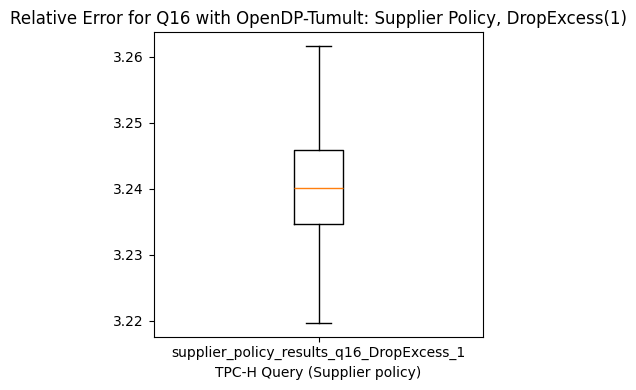

In [3]:
#Q16

# -------------------------
# CONFIG
# -------------------------
keys = ["p_brand","p_type","p_size"]
metrics = "supplier_cnt"

eps_val = 1
truth_path = "./output/no_dp/q16_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
test_case="q16_DropExcess_1"
OUTPUT="supplier_policy_results"
runs_glob = f"./output/{OUTPUT}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)
print("Q16")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

relerror = (
    per_run
    .select("avg_relerror_per_run")
    .dropna()
    .toPandas()
)

qerror = (
    per_run
    .select("avg_qerror_per_run")
    .dropna()
    .toPandas()
)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

key=f'{OUTPUT}_{test_case}'
with open(
    f"./output/{OUTPUT}/{key}.csv",
    "w"
) as f:
    f.write(key)
    f.write(",")
    f.write(",".join(str(x) for x in relerror.iloc[:, 0]))

tpch_query_results[key] = {
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
        "qerror": qerror,
        "relerror": relerror
    }

plt.figure(figsize=(4, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [key])
plt.xlabel("TPC-H Query (Supplier policy)")
plt.title("Relative Error for Q16 with OpenDP-Tumult: Supplier Policy, DropExcess(1)")
plt.tight_layout()
plt.show()


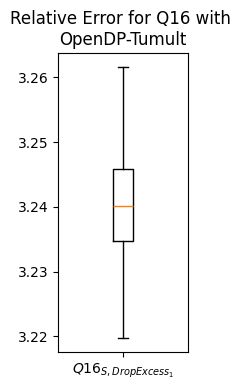

In [4]:
plt.figure(figsize=(2, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [r"$Q16_{S,DropExcess_1}$"])
plt.title("Relative Error for Q16 with \nOpenDP-Tumult")
plt.tight_layout()
plt.show()

Q16


Distinct runs = 1000


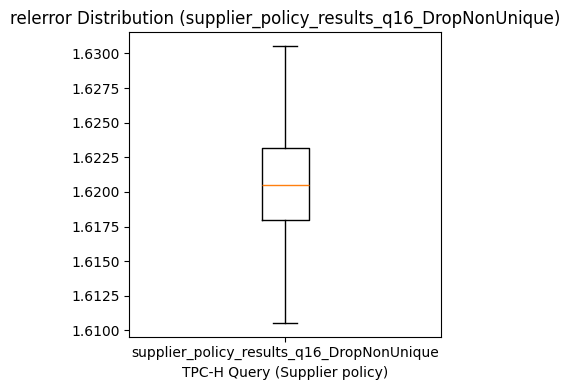

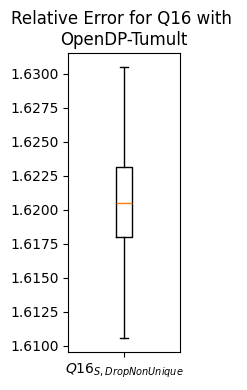

In [5]:
#Q16

# -------------------------
# CONFIG
# -------------------------
keys = ["p_brand","p_type","p_size"]
metrics = "supplier_cnt"

eps_val = 1
truth_path = "./output/no_dp/q16_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
test_case="q16_DropNonUnique"
OUTPUT="supplier_policy_results"
runs_glob = f"./output/{OUTPUT}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)
print("Q16")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

relerror = (
    per_run
    .select("avg_relerror_per_run")
    .dropna()
    .toPandas()
)



qerror = (
    per_run
    .select("avg_qerror_per_run")
    .dropna()
    .toPandas()
)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

key=f'{OUTPUT}_{test_case}'

with open(
    f"./output/{OUTPUT}/{key}.csv",
    "w"
) as f:
    f.write(key)
    f.write(",")
    f.write(",".join(str(x) for x in relerror.iloc[:, 0]))

tpch_query_results[key] = {
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
        "qerror": qerror,
        "relerror": relerror
    }

plt.figure(figsize=(4, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [key])
plt.xlabel("TPC-H Query (Supplier policy)")
plt.title("relerror Distribution " + f"({key})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [r"$Q16_{S,DropNonUnique}$"])
plt.title("Relative Error for Q16 with \nOpenDP-Tumult")
plt.tight_layout()
plt.show()


Q13
Distinct runs = 999


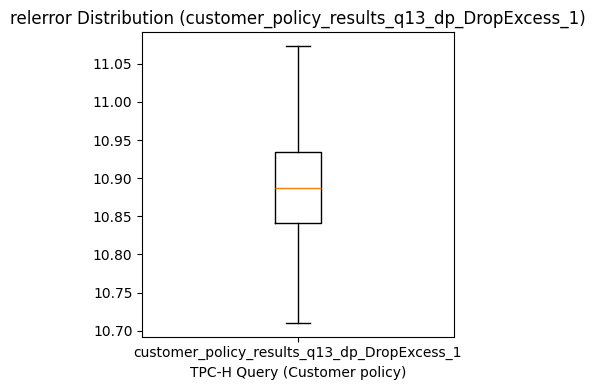

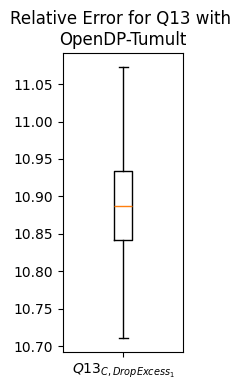

In [6]:
#Q13

# -------------------------
# CONFIG
# -------------------------
keys = ["c_count"]
metrics = "custdist"

eps_val = 1
truth_path = "./output/no_dp/q13_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
test_case="q13_dp_DropExcess_1"
OUTPUT="customer_policy_results"
runs_glob = f"./output/{OUTPUT}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

print("Q13")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

relerror = (
    per_run
    .select("avg_relerror_per_run")
    .dropna()
    .toPandas()
)

qerror = (
    per_run
    .select("avg_qerror_per_run")
    .dropna()
    .toPandas()
)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

key=f'{OUTPUT}_{test_case}'
with open(
    f"./output/{OUTPUT}/{key}.csv",
    "w"
) as f:
    f.write(key)
    f.write(",")
    f.write(",".join(str(x) for x in relerror.iloc[:, 0]))
    
tpch_query_results[key] = {
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
        "qerror": qerror,
        "relerror": relerror
    }

plt.figure(figsize=(4, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [key])
plt.xlabel("TPC-H Query (Customer policy)")
plt.title("relerror Distribution " + f"({key})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [r"$Q13_{C,DropExcess_1}$"])
plt.title("Relative Error for Q13 with \nOpenDP-Tumult")
plt.tight_layout()
plt.show()

Q13
Distinct runs = 1000


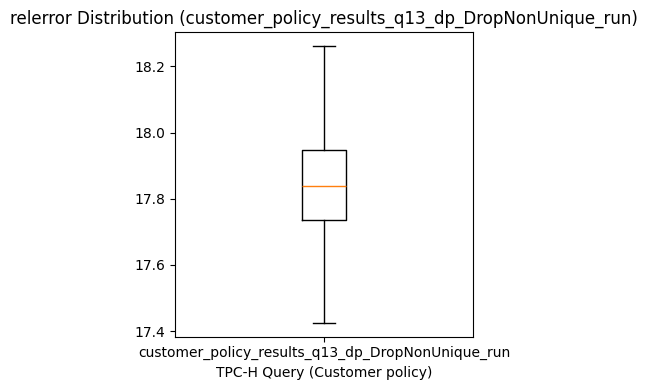

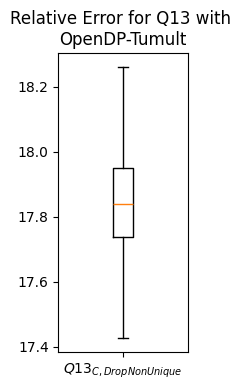

In [7]:
#Q13

# -------------------------
# CONFIG
# -------------------------
keys = ["c_count"]
metrics = "custdist"

eps_val = 1
truth_path = "./output/no_dp/q13_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
OUTPUT="customer_policy_results"
test_case="q13_dp_DropNonUnique_run"
runs_glob = f"./output/{OUTPUT}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

print("Q13")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

relerror = (
    per_run
    .select("avg_relerror_per_run")
    .dropna()
    .toPandas()
)

qerror = (
    per_run
    .select("avg_qerror_per_run")
    .dropna()
    .toPandas()
)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

key=f'{OUTPUT}_{test_case}'
with open(
    f"./output/{OUTPUT}/{key}.csv",
    "w"
) as f:
    f.write(key)
    f.write(",")
    f.write(",".join(str(x) for x in relerror.iloc[:, 0]))
    
tpch_query_results[key] = {
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
        "qerror": qerror,
        "relerror": relerror
    }

plt.figure(figsize=(4, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [key])
plt.xlabel("TPC-H Query (Customer policy)")
plt.title("relerror Distribution " + f"({key})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2, 4))
plt.boxplot(relerror, showfliers=False)
plt.xticks([1], [r"$Q13_{C,DropNonUnique}$"])
plt.title("Relative Error for Q13 with \nOpenDP-Tumult")
plt.tight_layout()
plt.show()

***


opendp eval with TPCH and supplier policy Results Summary:
Average Qerror per query: [162.01907341333336, 81.02929799466676, 608.2021191311442, 1107.152784106976]
Average RelError per query: [3.2403814682666763, 1.620585959893278, 10.888342020566464, 17.841900024979477]
Queries evaluated: ['$q16_{S,DropExcess_1}$', '$q16_{S,DropNonUnique}$', '$q13_{C,DropExcess_1}$', '$q13_{C,DropNonUnique}$']


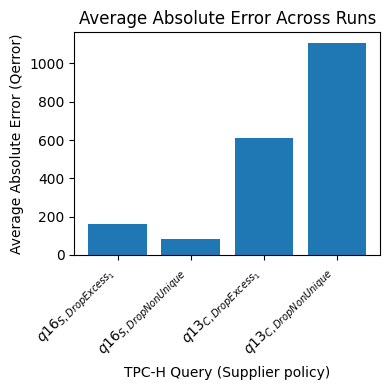

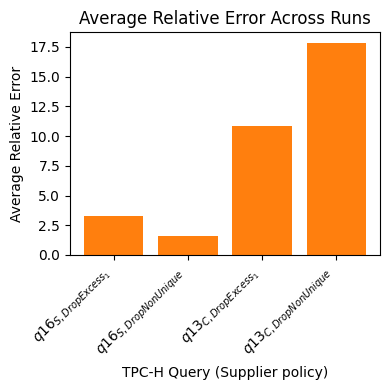

/var/folders/xm/h9wx824x47311kz87v7c1g440000gn/T/ipykernel_1327/49009949.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


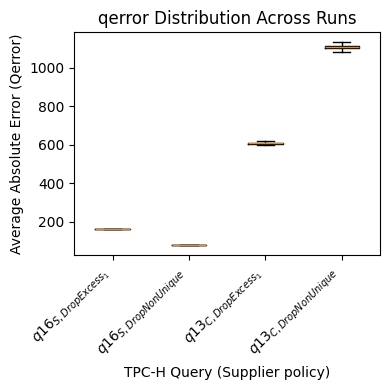

/var/folders/xm/h9wx824x47311kz87v7c1g440000gn/T/ipykernel_1327/49009949.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


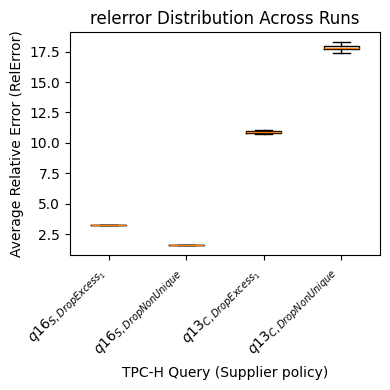

In [8]:
print("opendp eval with TPCH and supplier policy Results Summary:")

import matplotlib.pyplot as plt

# Use a stable list of labels (convert to strings) and numeric positions for plotting
queries = list(tpch_query_results.keys())
#queries_label = [str(q) for q in queries]


avg_qerror = [tpch_query_results[q]["mean_qerror_over_runs"] for q in queries]
raw_qerror = [tpch_query_results[q]["qerror"] for q in queries]
print("Average Qerror per query:", avg_qerror)
avg_relerror = [tpch_query_results[q]["mean_relerror_over_runs"] for q in queries]
print("Average RelError per query:", avg_relerror)

queries_label = []
for q in queries:
    if str(q) == "customer_policy_results_q13_dp_DropNonUnique_run":
        queries_label.append(r"$q13_{C,DropNonUnique}$")
    elif str(q) == "customer_policy_results_q13_dp_DropExcess_1":
        queries_label.append(r"$q13_{C,DropExcess_1}$")
    elif str(q) == "supplier_policy_results_q16_DropNonUnique":
        queries_label.append(r"$q16_{S,DropNonUnique}$")
    elif str(q) == "supplier_policy_results_q16_DropExcess_1":
        queries_label.append(r"$q16_{S,DropExcess_1}$")
print("Queries evaluated:", queries_label)
positions = list(range(len(queries_label)))

# Absolute error bar plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(positions, avg_qerror, color='tab:blue')
ax.set_xticks(positions)
ax.set_xticklabels(queries_label, rotation=45, ha='right')
ax.set_xlabel("TPC-H Query (Supplier policy)")
ax.set_ylabel("Average Absolute Error (Qerror)")
ax.set_title("Average Absolute Error Across Runs")
plt.tight_layout()
plt.show()

# Relative error bar plot
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.bar(positions, avg_relerror, color='tab:orange')
ax2.set_xticks(positions)
ax2.set_xticklabels(queries_label, rotation=45, ha='right')
ax2.set_xlabel("TPC-H Query (Supplier policy)")
ax2.set_ylabel("Average Relative Error")
ax2.set_title("Average Relative Error Across Runs")
plt.tight_layout()
plt.show()

raw_qerror = [tpch_query_results[q]["qerror"] for q in queries]
raw_relerror = [tpch_query_results[q]["relerror"] for q in queries]
import numpy as np
raw_qerror_1d = [np.asarray(x).ravel() for x in raw_qerror]

plt.figure(figsize=(4, 4))
plt.boxplot(
    raw_qerror_1d,
    labels=queries_label,
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("TPC-H Query (Supplier policy)")
plt.ylabel("Average Absolute Error (Qerror)")
plt.title("qerror Distribution Across Runs")
plt.tight_layout()
plt.show()

raw_relerror_1d = [np.asarray(x).ravel() for x in raw_relerror]

plt.figure(figsize=(4, 4))
plt.boxplot(
    raw_relerror_1d,
    labels=queries_label,
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.xlabel("TPC-H Query (Supplier policy)")
plt.ylabel("Average Relative Error (RelError)")
plt.title("relerror Distribution Across Runs")
plt.tight_layout()
plt.show()